# "Machine Learning \& Deep Learning Applications in Modern Power Systems"
## Department of Electrical Engineering - PMEC, Berhampur
### Instructor: Dr. Suryalok Dash 

# Day 2: Exercise Notebook
**Task:** Complete the missing code sections marked with `### YOUR CODE HERE ###`.

In [1]:
import torch
import numpy as np

# We have raw data from 3 sensors at a substation
sensor_data_np = np.array([[220.0, 15.2, 50.1], [218.5, 16.0, 49.9]])

# Task 1: Convert 'sensor_data_np' into a PyTorch tensor with dtype=torch.float32. Name it 'sensor_tensor'.
sensor_tensor = torch.tensor(sensor_data_np, dtype=torch.float32)

# Task 2: Print the shape of 'sensor_tensor'
print("Tensor Shape:", sensor_tensor.shape)

# Task 3: Multiply 'sensor_tensor' by 2 using standard mathematical operators and print the result.
doubled_tensor = sensor_tensor * 2
print("Doubled Tensor:\n", doubled_tensor)

Tensor Shape: torch.Size([2, 3])
Doubled Tensor:
 tensor([[440.0000,  30.4000, 100.2000],
        [437.0000,  32.0000,  99.8000]])


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Generate synthetic transformer health data (4 features predicting Remaining Useful Life)
np.random.seed(10)
X_data = np.random.uniform(0, 100, (800, 4))
y_data = (X_data[:, 0]*2 + X_data[:, 1]*0.5 - X_data[:, 2]*1.2 + 500).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=10)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Task 4: Convert 'X_train_s' and 'y_train' to float32 PyTorch tensors. Name them 'X_train_t' and 'y_train_t'.
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

# Task 5: Convert 'X_test_s' and 'y_test' to float32 PyTorch tensors. Name them 'X_test_t' and 'y_test_t'.
X_test_t = torch.tensor(X_test_s, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# Task 6: Print the shape of 'X_train_t' to confirm it has 4 features (columns).
print("Training Features Shape:", X_train_t.shape)

Training Features Shape: torch.Size([640, 4])


In [4]:
import torch.nn as nn
import torch.optim as optim

# Task 7: Define a Sequential model named 'model'.
# Structure: 
# - Linear layer (4 inputs, 32 outputs)
# - ReLU activation
# - Linear layer (32 inputs, 1 output)
model = nn.Sequential(
    nn.Linear(4, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

# Task 8: Define the loss function as Mean Squared Error (MSELoss). Name it 'criterion'.
criterion = nn.MSELoss()

# Task 9: Initialize the Adam optimizer. Pass it the model.parameters() and set the learning rate (lr) to 0.05. Name it 'optimizer'.
optimizer = optim.Adam(model.parameters(), lr=0.05)

In [5]:
epochs = 100
loss_history = []

for epoch in range(epochs):
    # Task 10: Perform the forward pass. Pass 'X_train_t' into the model to get 'predictions'.
    predictions =  model(X_train_t)
    
    # Task 11: Calculate the loss by passing 'predictions' and 'y_train_t' into your 'criterion'.
    loss = criterion(predictions, y_train_t)
    
    # Task 12: Execute the three mandatory backpropagation steps:
    # 1. Zero the gradients
    # 2. Perform the backward pass
    # 3. Step the optimizer
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())

print("Training complete. Final Loss:", loss.item())

Training complete. Final Loss: 3859.557861328125


Final Test Loss: 4400.24853515625


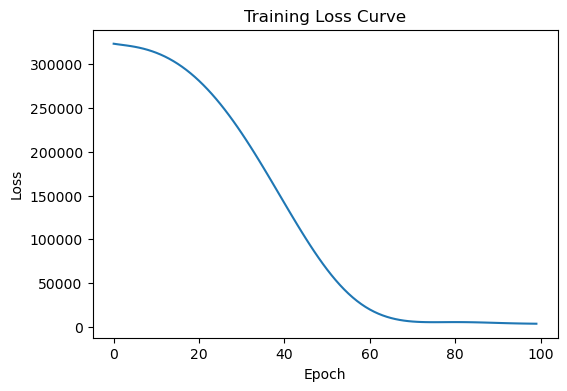

In [6]:
import matplotlib.pyplot as plt

# Task 13: Put the model into evaluation mode using the .eval() method.
model.eval()

# Task 14: Use torch.no_grad() to calculate the final test loss. 
# Pass 'X_test_t' to the model to get 'test_preds', then calculate the loss using 'y_test_t'.
with torch.no_grad():
    test_preds = model(X_test_t)
    test_loss = criterion(test_preds, y_test_t)
    print("Final Test Loss:", test_loss.item())

# Task 15: Plot the 'loss_history' list using matplotlib to visualize the training curve.
# Add a title and x/y labels.
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()